In [1]:
import sys
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import yaml

# Make sure your project directory is visible to the notebook
sys.path.append(os.path.abspath('../'))

from src.data.dataset import INRDataset
from src.models.gpt import INRGPT

class YamlConfig:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Open your local file directly instead of pulling from the checkpoint
config_path = "../config.yaml"  # Make sure this points to your file!
with open(config_path, 'r') as f:
    config_data = yaml.safe_load(f)
config = YamlConfig(config_data)

# 2. Instantiate the model structural framework
model = INRGPT(config).to(device)

try:
    import __main__
    # If YamlConfig is in your notebook, this line registers it:
    torch.serialization.add_safe_globals([__main__.YamlConfig])
except Exception:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Alternative approach: Force weights_only=False if you fully trust this checkpoint file
checkpoint = torch.load("../checkpoints/inr_gpt.pt", map_location=device, weights_only=False)

# 3. Load the state dict properly
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("🟢 Checkpoint loaded successfully with genuine trained parameters!")

number of parameters: 0.02M
🟢 Checkpoint loaded successfully with genuine trained parameters!


In [3]:
test_dataset = INRDataset(folder_path="../data/processed_inrs", split='test')
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)

total_test_loss = 0.0
with torch.no_grad():
    for batch in test_loader:
        x_neurons = batch['x_neurons'].to(device)
        layer_ids = batch['layer_ids'].to(device)
        target_layer_ids = batch['target_layer_ids'].to(device)
        y_neurons = batch['y_neurons'].to(device)
        predictions = model(x_neurons, layer_ids, target_layer_ids)
        loss = F.mse_loss(predictions, y_neurons)
        total_test_loss += loss.item()
print(f"✅ Global Test Set MSE: {total_test_loss / len(test_loader):.6f}")

KeyboardInterrupt: 

In [51]:
train_dataset = INRDataset(folder_path="../data/processed_inrs_1", split='train')
sample_idx = 0
sample = train_dataset[sample_idx]

prompt_length = 64
max_gen_length = len(sample['x_neurons'])  # Full length of the network sequence

# 2. Pre-allocate your full sequence templates directly on the device.
# This prevents you from needing to concatenate layer IDs or target IDs at all!
full_layer_ids = sample['layer_ids'].unsqueeze(0).to(device)         # Shape: [1, max_gen_length]
full_target_ids = sample['target_layer_ids'].unsqueeze(0).to(device) # Shape: [1, max_gen_length]

# 3. Initialize your weights matrix with the prompt, leaving space for the rest
# Shape: [1, max_gen_length, 33]
gen_x = torch.zeros((1, max_gen_length + 1, 33), device=device)
gen_x[0, :prompt_length] = sample['x_neurons'][:prompt_length].to(device)

print("🚀 Running clean generation loop...")

# 4. The Loop: Just slide a window forward step-by-step
with torch.no_grad():
    for t in range(prompt_length, max_gen_length + 1):
        
        # Slice out the exact historical windows up to the current timeline step 't'
        current_x = gen_x[:, :t, :]             # Shape: [1, t, 33]
        current_layers = full_layer_ids[:, :t]   # Shape: [1, t]
        current_targets = full_target_ids[:, :t] # Shape: [1, t]
        
        # Predict the next step
        logits = model(current_x, current_layers, current_targets)
        
        # Extract the absolute newest predicted token and inject it right into our template slot
        next_token = logits[:, -1, :] # Shape: [1, 33]
        gen_x[0, t] = next_token

print(f"✅ Generation complete! Output Matrix Shape: {gen_x.shape}")

# Unpack for plotting/evaluation
generated_weights = gen_x.squeeze(0).cpu()
ground_truth_weights = sample['x_neurons'].cpu()

🚀 Running clean generation loop...
✅ Generation complete! Output Matrix Shape: torch.Size([1, 65, 33])


In [52]:
torch.save({
    'neurons': generated_weights,           # Your live [65, 33] tensor
    'layer_ids': torch.cat([sample['layer_ids'], torch.tensor([sample['target_layer_ids'][-1]])]).cpu()
}, "data/temp_generated.pt")

In [53]:
from src.utils.prepare_data import INRDataProcessor
processor = INRDataProcessor()
state_dict = processor.reconstruct_state_dict("data/temp_generated.pt")

# 3. Save your final functional model file
torch.save(state_dict, "data/final_reconstructed_model.pth")

In [54]:
import torch

# 1. Load a sample directly from the raw MNIST INR data you used for training
# (Replace this path with the actual path to your MNIST INR training data file, e.g., 'data/mnist_inr_train.pt')
try:
    dataset_sample = torch.load("data/mnist_png_training_0_1/checkpoints/model_final.pth", map_location="cpu")
    print("🟢 Successfully loaded dataset file!")
    
    # Let's inspect what a real sample looks like inside the paper's data structure
    if isinstance(dataset_sample, dict):
        print("Dataset Keys:", list(dataset_sample.keys()))
        # If it has a weights/biases key, let's print their exact dimensions
        if "weights" in dataset_sample:
            print("Real dataset weights shape:", [w.shape for w in dataset_sample["weights"]])
        if "biases" in dataset_sample:
            print("Real dataset biases shape:", [b.shape for b in dataset_sample["biases"]])
            
    elif isinstance(dataset_sample, list):
        print("Dataset is a list. First element type:", type(dataset_sample[0]))
        
except Exception as e:
    print("❌ Could not open dataset file directly. Let's inspect your generated checkpoint instead:")
    print(e)

# 2. Print your exact reconstructed model shapes to compare
checkpoint = torch.load("data/final_reconstructed_model.pth", map_location="cpu")
print("\n🔍 Your final_reconstructed_model.pth shapes:")
for k, v in checkpoint.items():
    print(f"Key: {k} | Shape: {list(v.shape)} | Mean: {v.mean().item():.4f} | Std: {v.std().item():.4f}")

🟢 Successfully loaded dataset file!
Dataset Keys: ['seq.0.weight', 'seq.0.bias', 'seq.1.weight', 'seq.1.bias', 'seq.2.weight', 'seq.2.bias']

🔍 Your final_reconstructed_model.pth shapes:
Key: seq.0.weight | Shape: [32, 2] | Mean: -0.0067 | Std: 0.0653
Key: seq.0.bias | Shape: [32] | Mean: 0.0044 | Std: 0.0247
Key: seq.1.weight | Shape: [32, 32] | Mean: -0.0001 | Std: 0.0178
Key: seq.1.bias | Shape: [32] | Mean: 0.0029 | Std: 0.0092
Key: seq.2.weight | Shape: [1, 32] | Mean: 0.0067 | Std: 0.1236
Key: seq.2.bias | Shape: [1] | Mean: -0.1048 | Std: nan


/tmp/ipykernel_1363/314587497.py:29: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  print(f"Key: {k} | Shape: {list(v.shape)} | Mean: {v.mean().item():.4f} | Std: {v.std().item():.4f}")


🚀 Passing perfectly shaped dimensions through BatchSiren...
🎨 Rendering image...


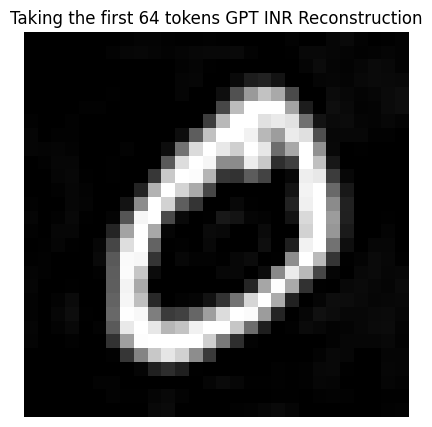

In [55]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from pathlib import Path
current_dir = Path(os.getcwd())
sys.path.append(str(Path("..") / "external" / "neuralgraphs"))
from experiments.data import BatchSiren

# 1. Setup basic dimensions
img_shape = (28, 28)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load your raw .pth dictionary file directly
checkpoint = torch.load("data/final_reconstructed_model.pth", map_location=device)

# 3. Shape the tensors exactly how BatchSiren's Einops layers demand them:
# Weights need to be: [batch_size=1, in_features, out_features, 1]
# Note: PyTorch saves weights as [out_features, in_features], so we transpose them (.T) to match (i, o)
w0 = checkpoint["seq.0.weight"].T.unsqueeze(0).unsqueeze(-1)  # [1, 2, 32, 1]
w1 = checkpoint["seq.1.weight"].T.unsqueeze(0).unsqueeze(-1)  # [1, 32, 32, 1]
w2 = checkpoint["seq.2.weight"].T.unsqueeze(0).unsqueeze(-1)  # [1, 32, 1, 1]

# Biases need to be: [batch_size=1, out_features, 1]
b0 = checkpoint["seq.0.bias"].unsqueeze(0).unsqueeze(-1)      # [1, 32, 1]
b1 = checkpoint["seq.1.bias"].unsqueeze(0).unsqueeze(-1)      # [1, 32, 1]
b2 = checkpoint["seq.2.bias"].unsqueeze(0).unsqueeze(-1)      # [1, 1, 1]

# 4. Group them into lists matching the layer-by-layer zip structure
weights_input = [w0, w1, w2]
biases_input = [b0, b1, b2]

# 5. Initialize the model and run the forward pass
# (hidden_features=32 matches the layers in your file)
inr_model = BatchSiren(2, 1, hidden_features=32, img_shape=img_shape).to(device)
inr_model.eval()

print("🚀 Passing perfectly shaped dimensions through BatchSiren...")

with torch.no_grad():
    # This will now pass smoothly through the zip loop and Rearrange functions!
    out = inr_model(weights_input, biases_input)
    
    # Reshape the output pixels back into the 2D image matrix
    out_image = out.transpose(1, 2).unflatten(2, img_shape)

print("🎨 Rendering image...")

# 6. Render and show the image
plt.figure(figsize=(5, 5))
plt.imshow(make_grid(out_image.cpu()).permute(1, 2, 0).clip(0, 1))
plt.title("Taking the first 64 tokens GPT INR Reconstruction")
plt.axis("off")
plt.show()